### Setup

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from collections import OrderedDict

In [2]:
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

device

'cuda'

### Load Dataset

In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

columns = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year", "origin", ]

df = pd.read_csv(url, names=columns, na_values="?", sep=r"\s+", usecols=range(8), )

df = df.dropna()

df = df.dropna()

print(df.shape)

df.head()

(392, 8)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


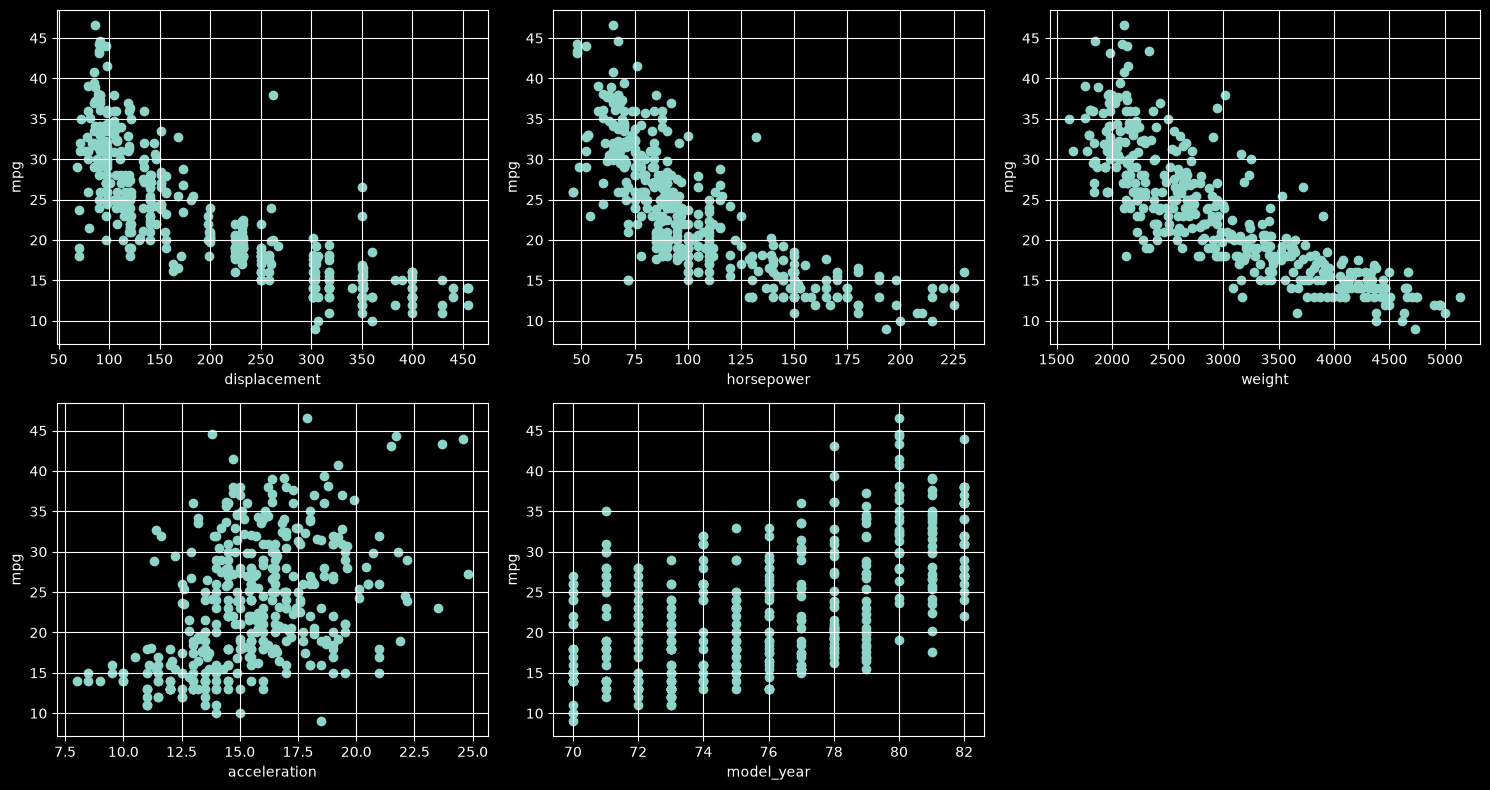

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, feature in zip(axes.flat, ["displacement", "horsepower", "weight", "acceleration", "model_year"]):
    ax.scatter(df[feature].values, df["mpg"].values)
    ax.set_xlabel(feature)
    ax.set_ylabel("mpg")
    ax.grid()

axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

In [5]:
features = ["displacement", "horsepower", "weight", "acceleration", "model_year", ]

X = torch.tensor(df[features].values, dtype=torch.float32, device=device)

y = torch.tensor(df[["mpg"]].values, dtype=torch.float32, device=device)

In [6]:
X_mean = X.mean()
X_std = X.std()
X = (X-X_mean)/X_std

y_mean = y.mean()
y_std = y.std()
y = (y-y_mean)/y_std

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([313, 5]),
 torch.Size([79, 5]),
 torch.Size([313, 1]),
 torch.Size([79, 1]))

### Model

In [8]:
class ModelNNN(nn.Module):
    def __init__(self, input_n, M, ns, output_n):
        super().__init__()
        layers = {}
        ns.insert(0, input_n)
        c = 0
        for layer in range(M):
            layers.update({str(c) : nn.Linear(ns[layer], ns[layer+1]), str(c+1): nn.ReLU()})
            c += 2
        self.block = nn.Sequential(OrderedDict(layers))
        self.output_layer = nn.Linear(ns[-1], output_n)

    def forward(self, X):
        block_output = self.block(X)
        return self.output_layer(block_output)

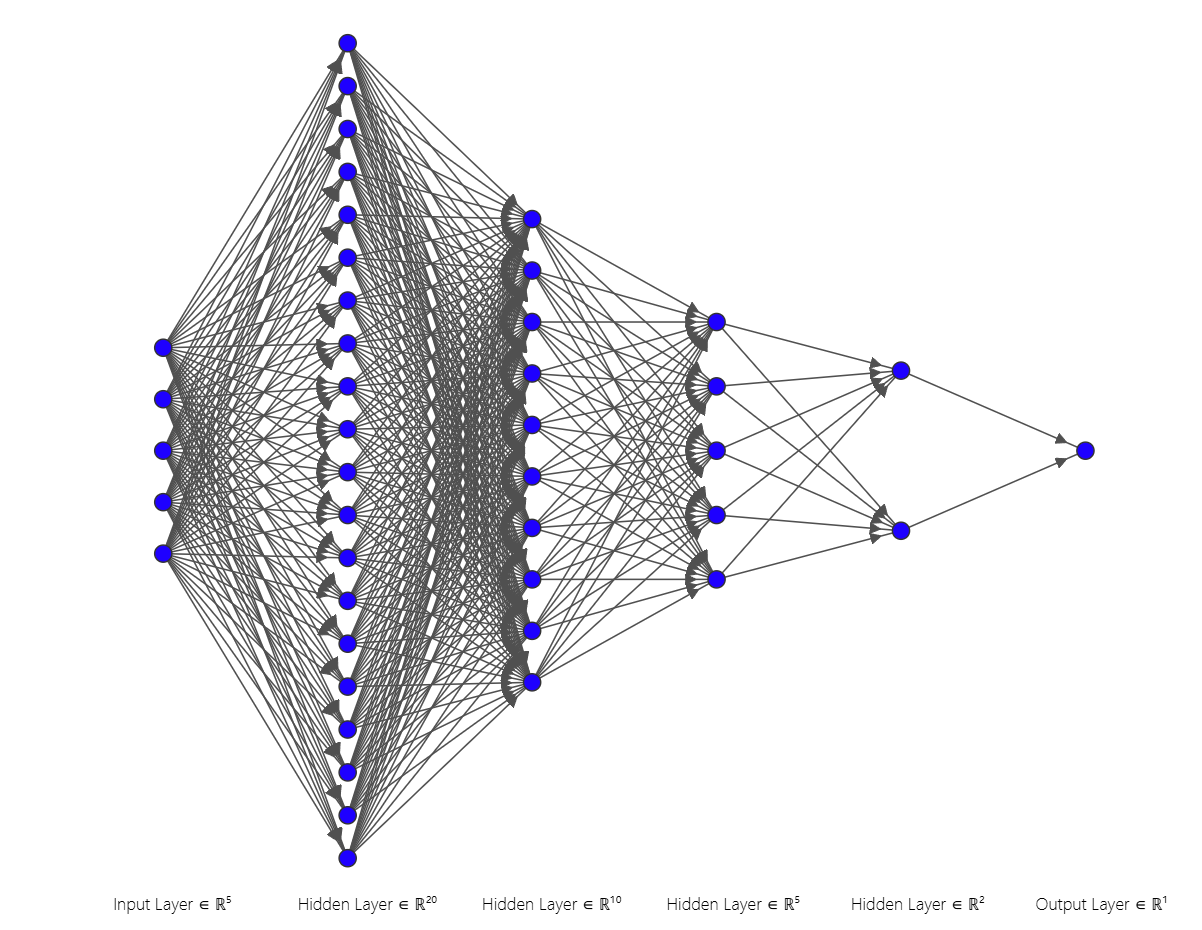
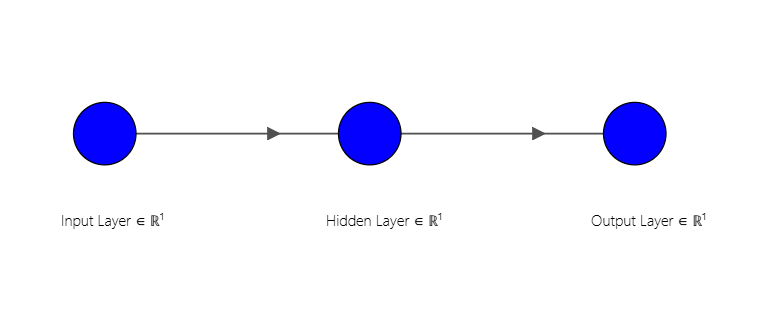
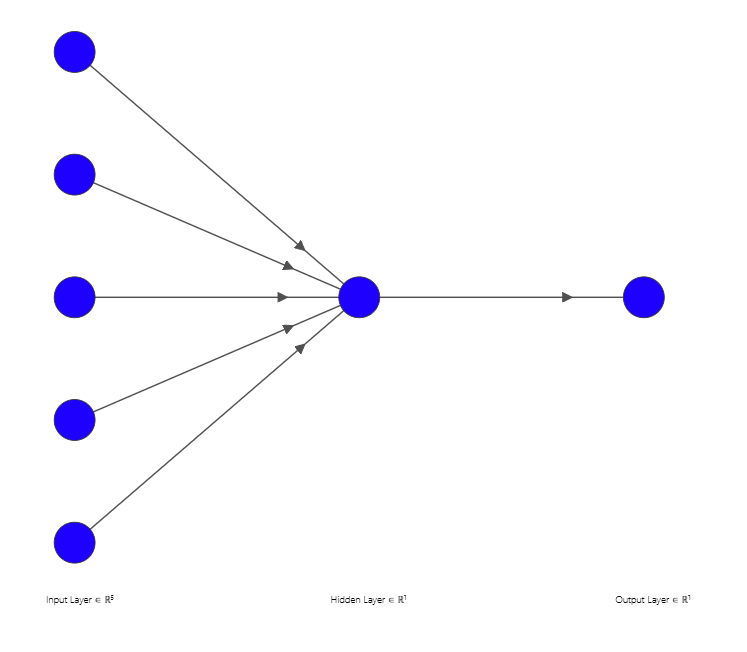
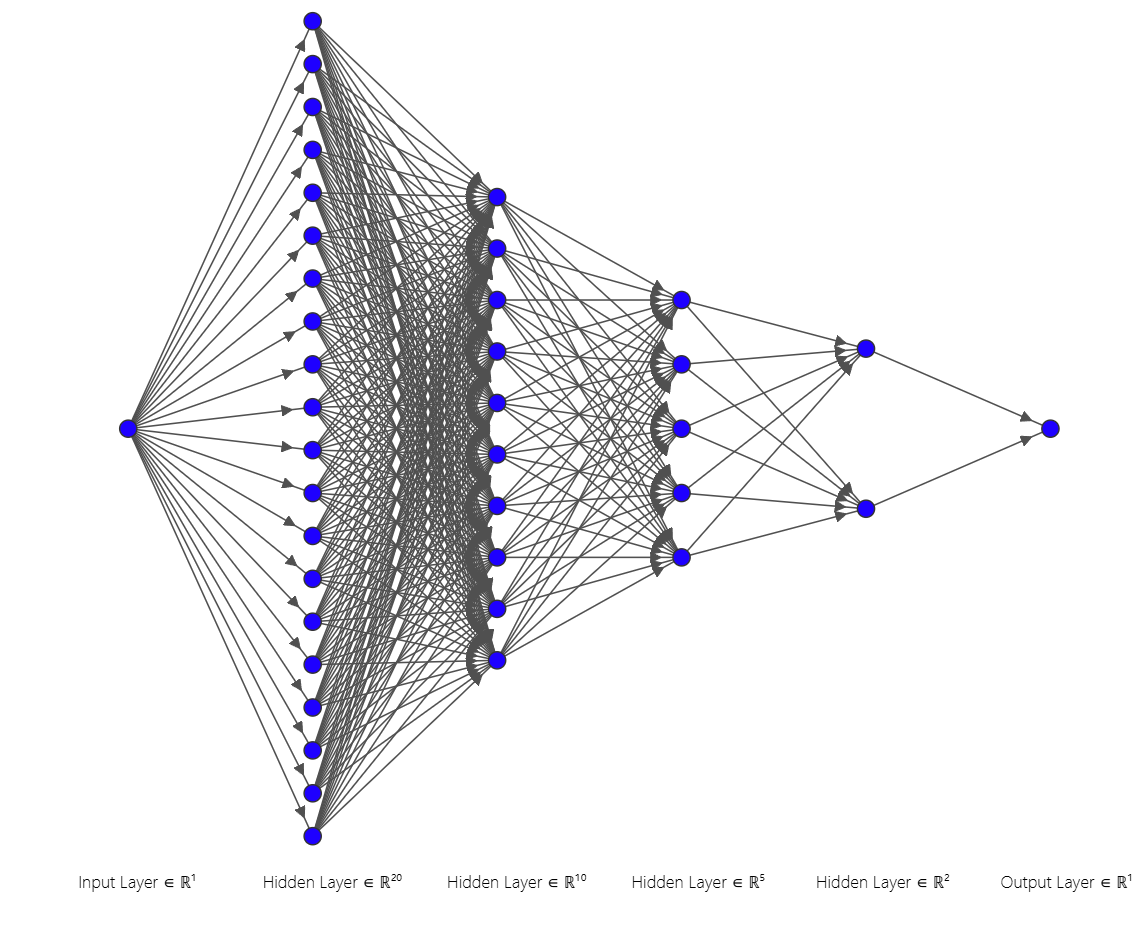

In [9]:
model = ModelNNN(5, 4, [20, 10, 5, 2], 1)
model = model.to(device)
model

ModelNNN(
  (block): Sequential(
    (0): Linear(in_features=5, out_features=20, bias=True)
    (1): ReLU()
    (2): Linear(in_features=20, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=5, bias=True)
    (5): ReLU()
    (6): Linear(in_features=5, out_features=2, bias=True)
    (7): ReLU()
  )
  (output_layer): Linear(in_features=2, out_features=1, bias=True)
)

### Training

In [10]:
def train(model, optimizer, criterion, X, y, n_epochs):
    losses = []
    for epoch in range(n_epochs):
        y_pred = model(X)
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        losses.append(loss.item())
        print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {loss.item()}")
    return losses

In [11]:
learning_rate = 0.1
n_epochs = 30

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()

In [12]:
loss = train(model, optimizer, mse, X_train, y_train, n_epochs)

Epoch 1/30, Loss: 1.5050708055496216
Epoch 2/30, Loss: 1.230631947517395
Epoch 3/30, Loss: 1.137973427772522
Epoch 4/30, Loss: 1.0873719453811646
Epoch 5/30, Loss: 1.058544635772705
Epoch 6/30, Loss: 1.0416483879089355
Epoch 7/30, Loss: 1.0314695835113525
Epoch 8/30, Loss: 1.0251514911651611
Epoch 9/30, Loss: 1.0211526155471802
Epoch 10/30, Loss: 1.018569827079773
Epoch 11/30, Loss: 1.0168792009353638
Epoch 12/30, Loss: 1.0157335996627808
Epoch 13/30, Loss: 1.0149251222610474
Epoch 14/30, Loss: 1.0143089294433594
Epoch 15/30, Loss: 1.0138052701950073
Epoch 16/30, Loss: 1.0133693218231201
Epoch 17/30, Loss: 1.0129711627960205
Epoch 18/30, Loss: 1.0125880241394043
Epoch 19/30, Loss: 1.0122120380401611
Epoch 20/30, Loss: 1.0118340253829956
Epoch 21/30, Loss: 1.011443018913269
Epoch 22/30, Loss: 1.0110360383987427
Epoch 23/30, Loss: 1.0106134414672852
Epoch 24/30, Loss: 1.0101723670959473
Epoch 25/30, Loss: 1.0097107887268066
Epoch 26/30, Loss: 1.0092288255691528
Epoch 27/30, Loss: 1.00872

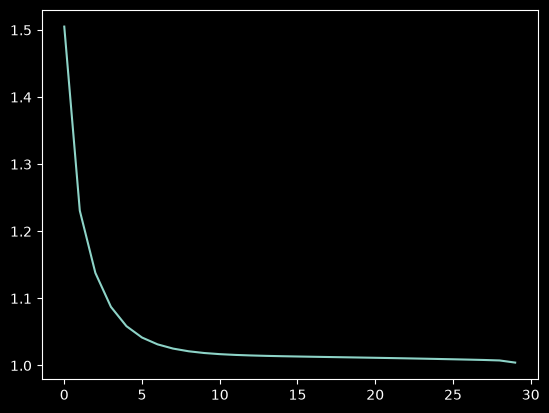

In [13]:
plt.plot(list(range(n_epochs)), loss)

### Evaluate

In [14]:
def evaluate(model, X, y, metric_fn, aggregate_fn=torch.mean):
    model.eval()
    metrics = []
    with torch.no_grad():
        for X_data, y_data in zip(X, y):
            y_pred = model(X_data)
            metric = metric_fn(y_pred, y_data)
            metrics.append(metric)
    return aggregate_fn(torch.stack(metrics))

In [15]:
evaluate(model, X_test, y_test, mse)

tensor(0.8752, device='cuda:0')

end